In [13]:
# MINI PROJECT
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Divyadharshiny-codebooster-internship-2026/student_performance.csv')

In [2]:
import sqlite3
import matplotlib.pyplot as plt

In [3]:
df["total_score"] = df["math_score"] + df["programming_score"]
print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  total_score  
0                     92     Mumbai            2023          176  
1                     87  Ahmedabad 

In [4]:
conn = sqlite3.connect("students.db")

In [5]:
df.to_sql("students", conn, if_exists="replace", index=False)

30

In [7]:
query1 = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
"""
avg_math_df = pd.read_sql_query(query1, conn)
print(avg_math_df)

         department   avg_math
0             Civil  63.400000
1  Computer Science  85.615385
2       Electronics  71.000000
3        Mechanical  71.000000


In [8]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""
count_df = pd.read_sql_query(query2, conn)
print(count_df)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [9]:
query3 = """
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
top_students_df = pd.read_sql_query(query3, conn)
print(top_students_df)

             name  total_score
0      Ananya Das          192
1     Tanvi Mehta          189
2      Arjun Nair          187
3  Akanksha Yadav          185
4  Swati Kulkarni          182
5     Divya Singh          181
6    Aarav Sharma          176
7       Amit Bose          175


In [10]:
query4 = """
SELECT gender,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""
attendance_df = pd.read_sql_query(query4, conn)
print(attendance_df)

   gender  avg_attendance
0  Female       88.533333
1    Male       80.466667


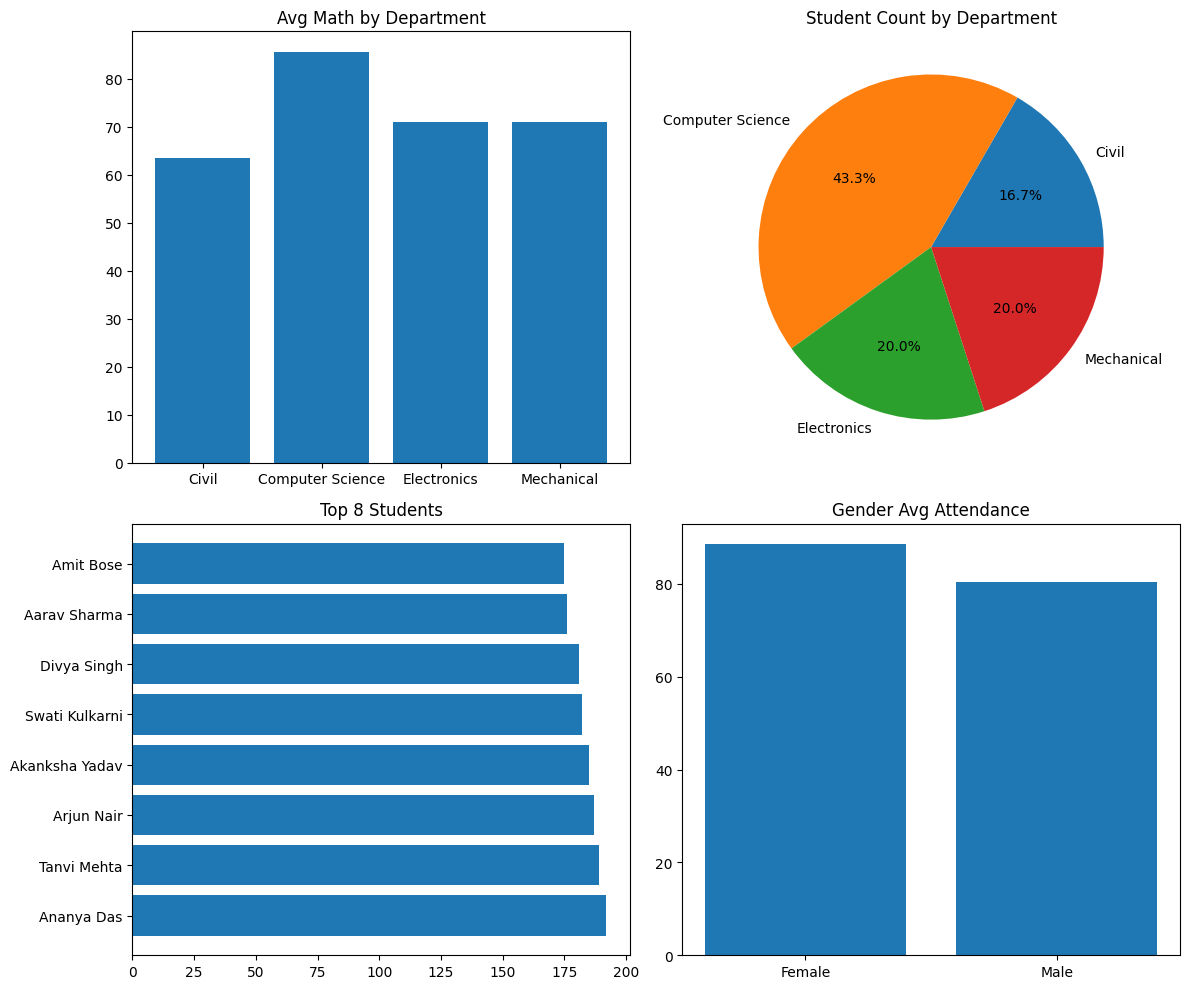

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# -----------------------------------------
# Panel 1: Avg Math by Department
# -----------------------------------------
axes[0,0].bar(avg_math_df["department"], avg_math_df["avg_math"])
axes[0,0].set_title("Avg Math by Department")
# -----------------------------------------
# Panel 2: Student Count Pie Chart
# -----------------------------------------
axes[0,1].pie(
    count_df["student_count"],
    labels=count_df["department"],
    autopct='%1.1f%%'
)
axes[0,1].set_title("Student Count by Department")
# -----------------------------------------
# Panel 3: Top 8 Students Horizontal Bar
# -----------------------------------------
axes[1,0].barh(
    top_students_df["name"],
    top_students_df["total_score"]
)
axes[1,0].set_title("Top 8 Students")
# -----------------------------------------
# Panel 4: Gender Avg Attendance
# -----------------------------------------
axes[1,1].bar(
    attendance_df["gender"],
    attendance_df["avg_attendance"]
)
axes[1,1].set_title("Gender Avg Attendance")
plt.tight_layout()
plt.show()

In [14]:
# PRACTICE QUESTION
query = """
SELECT AVG(programming_score) AS avg_programming
FROM students
WHERE gender = 'Female'
"""
result = pd.read_sql_query(query, conn)
print(result)

   avg_programming
0             70.2


In [15]:
# PRACTICE QUESTION
query = """
SELECT *
FROM students
WHERE math_score > 80;
"""
result = pd.read_sql_query(query, conn)
print(result)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1005      Arjun Nair   19    Male  Computer Science         2   
2         1008     Divya Singh   19  Female  Computer Science         2   
3         1010      Ananya Das   19  Female  Computer Science         2   
4         1013      Suresh Rao   21    Male  Computer Science         2   
5         1016    Ritu Agarwal   20  Female       Electronics         2   
6         1018  Swati Kulkarni   19  Female  Computer Science         2   
7         1022     Tanvi Mehta   19  Female  Computer Science         2   
8         1025       Amit Bose   19    Male  Computer Science         2   
9         1027   Gaurav Shukla   21    Male  Computer Science         2   
10        1030  Akanksha Yadav   19  Female  Computer Science         2   

    math_score  science_score  english_score  programming_score  \
0           85             78   

In [16]:
# PRACTICE QUESTION
query = """
SELECT department,
AVG(math_score)
FROM students
GROUP BY department
HAVING AVG(math_score) > 80;
"""
result = pd.read_sql_query(query, conn)
print(result)

         department  AVG(math_score)
0  Computer Science        85.615385


In [17]:
query = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""
result = pd.read_sql_query(query, conn)
print(result)

         department  avg_attendance
0  Computer Science       90.692308


In [18]:
pd.read_sql_query(query1, conn)

,department,avg_math
0,Civil,63.400000
1,Computer Science,85.615385
2,Electronics,71.000000
3,Mechanical,71.000000


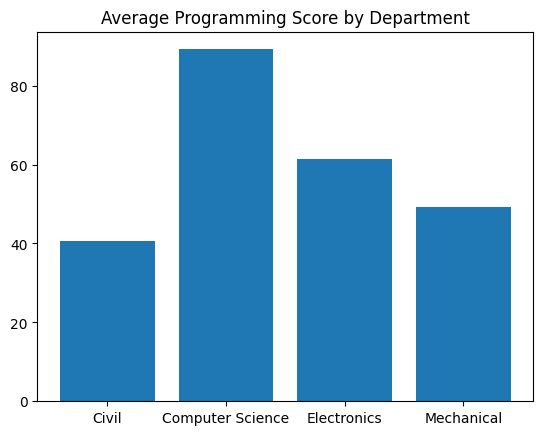

In [19]:
query = """
SELECT department,
AVG(programming_score) AS avg_programming
FROM students
GROUP BY department
"""
programming_df = pd.read_sql_query(query, conn)
plt.bar(
    programming_df["department"],
    programming_df["avg_programming"]
)
plt.title("Average Programming Score by Department")
plt.show()